# S&P 500 - Workforce Analysis Report (Weights considered)
## Comprehensive Statistical Analysis
---

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
import os
warnings.filterwarnings('ignore')

# Create output directory for plots
output_dir = 'output/company_overview'
os.makedirs(output_dir, exist_ok=True)
print(f"Output directory created: {output_dir}")

# Set McKinsey-style plotting parameters
plt.style.use('seaborn-v0_8-whitegrid')
MCKINSEY_BLUE = '#0077B6'
MCKINSEY_GRAY = '#4A4A4A'
MCKINSEY_LIGHT_BLUE = '#00B4D8'
MCKINSEY_PALETTE = ['#0077B6', '#00B4D8', '#90E0EF', '#CAF0F8', '#4A4A4A']

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica']
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['axes.edgecolor'] = '#CCCCCC'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['grid.alpha'] = 0.3

# Helper functions for weighted calculations
def weighted_value_counts(df, col, weight_col='weight'):
    """Calculate weighted counts for a categorical column"""
    valid = df[[col, weight_col]].dropna()
    return valid.groupby(col)[weight_col].sum().sort_values(ascending=False)

def weighted_mean(df, col, weight_col='weight'):
    """Calculate weighted mean"""
    valid = df[[col, weight_col]].dropna()
    return np.average(valid[col], weights=valid[weight_col])

def weighted_percentile(df, col, percentile, weight_col='weight'):
    """Calculate weighted percentile"""
    valid = df[[col, weight_col]].dropna().sort_values(col)
    cumsum = valid[weight_col].cumsum()
    cutoff = valid[weight_col].sum() * percentile
    return valid[col].iloc[np.searchsorted(cumsum, cutoff)]

def weighted_std(df, col, weight_col='weight'):
    """Calculate weighted standard deviation"""
    valid = df[[col, weight_col]].dropna()
    avg = np.average(valid[col], weights=valid[weight_col])
    variance = np.average((valid[col] - avg)**2, weights=valid[weight_col])
    return np.sqrt(variance)

print("Libraries loaded successfully")
print("✓ Weighted calculation helpers defined")

Output directory created: output/company_overview
Libraries loaded successfully
✓ Weighted calculation helpers defined


In [2]:
# Load the company data
df = pd.read_parquet('data/sp500_company_data.parquet')
print(f"Dataset loaded: {df.shape[0]:,} employees, {df.shape[1]} columns")
print(f"\nColumn names:")
print(df.columns.tolist())

Dataset loaded: 16,016,673 employees, 17 columns

Column names:
['user_id', 'position_id', 'rcid', 'seniority', 'country', 'salary', 'onet_code', 'startdate', 'enddate', 'weight', 'highest_degree', 'sex_predicted', 'ethnicity_predicted', 'ticker', 'naics_code', 'exchange_name', 'company']


In [ ]:
# Add onet_title column by mapping from dwa_times_normalized
dwa_df = pd.read_parquet('data/dwa_times_normalized.parquet')

# Create mapping from O*NET-SOC Code to Title (get unique pairs)
onet_mapping = dwa_df[['O*NET-SOC Code', 'Title']].drop_duplicates().set_index('O*NET-SOC Code')['Title']

# Map to add onets_title column
df['onets_title'] = df['onet_code'].map(onet_mapping)

# Statistics on mapping
mapped_count = df['onets_title'].notna().sum()
total_count = len(df)
unmapped_count = df['onet_code'].notna().sum() - mapped_count

print(f"✓ Added 'onets_title' column")
print(f"  Mapped: {mapped_count:,} / {total_count:,} rows ({mapped_count/total_count*100:.1f}%)")
print(f"  Unique O*NET titles (in reference data): {dwa_df['O*NET-SOC Code'].nunique():,}")
print(f"  Unique O*NET codes in employee data: {df['onet_code'].nunique():,}, Currently in ONETS database 1016.")
if unmapped_count > 0:
    unmapped_codes_list = sorted(df[df['onet_code'].notna() & df['onets_title'].isna()]['onet_code'].unique())
    print(f"  ⚠️ {len(unmapped_codes_list)} O*NET codes not in reference data (will be excluded from position analysis, these do not have task ratings data available.")
    print(f"\n  Unmapped codes:")
    for code in unmapped_codes_list:
        print(f"    {code}")

✓ Added 'onets_title' column
  Mapped: 14,613,324 / 16,016,673 rows (91.2%)
  Unique O*NET titles (in reference data): 923
  Unique O*NET codes in employee data: 1,009
  ⚠️ 93 O*NET codes not in reference data (will be excluded from position analysis)

  Unmapped codes:
    11-9039.00
    11-9179.00
    11-9199.00
    13-1199.00
    13-2099.00
    15-1299.00
    15-2099.00
    17-2199.00
    17-3019.00
    17-3029.00
    19-1029.00
    19-1099.00
    19-2099.00
    19-3039.00
    19-3099.00
    19-4099.00
    21-1019.00
    21-1029.00
    21-1099.00
    21-2099.00
    23-2099.00
    25-1069.00
    25-1199.00
    25-2059.00
    25-3099.00
    25-9049.00
    25-9099.00
    27-1019.00
    27-1029.00
    27-2099.00
    27-3099.00
    27-4099.00
    29-1029.00
    29-1129.00
    29-1229.00
    29-1249.00
    29-1299.00
    29-2099.00
    29-9099.00
    31-9099.00
    33-1099.00
    33-9099.00
    35-2019.00
    35-9099.00
    37-2019.00
    37-3019.00
    39-3019.00
    39-3099.00
    39-90

It appears that all the "All other" ONETs job categiries are not present in my pi, ARS file. Thats probs bc we are missing some occs that did not have a task time value.

In [4]:
# Display first few rows and data types
print("\n=== Data Preview ===")
display(df.head())
print("\n=== Data Types ===")
display(df.dtypes)
print("\n=== Missing Values ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})
display(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False))


=== Data Preview ===


,user_id,position_id,rcid,seniority,country,salary,onet_code,startdate,enddate,weight,highest_degree,sex_predicted,ethnicity_predicted,ticker,naics_code,exchange_name,company,onets_title
0,655444319.0,-7785932349259996160.0,68.0,2,United States,83775.55,17-2112.03,2012-05-01,<NA>,1.249402,<NA>,M,Black,WAB,336510,New York Stock Exchange,Westinghouse Air Brake Technologies Corp.,Manufacturing Engineers
1,1691194.0,-4185719328929451008.0,68.0,3,United States,131183.48,17-2199.06,1992-08-01,<NA>,1.015331,Bachelor,M,White,WAB,336510,New York Stock Exchange,Westinghouse Air Brake Technologies Corp.,Microsystems Engineers
2,1691194.0,-861084181087021824.0,68.0,4,United States,133435.49,17-2199.00,2017-05-01,<NA>,1.015331,Bachelor,M,White,WAB,336510,New York Stock Exchange,Westinghouse Air Brake Technologies Corp.,NaN
3,2763094.0,-8711480916433658880.0,68.0,2,United States,73069.44,11-3061.00,<NA>,<NA>,1.094262,<NA>,M,White,WAB,336510,New York Stock Exchange,Westinghouse Air Brake Technologies Corp.,Purchasing Managers
4,3042300.0,5710354076206946304.0,68.0,2,United Kingdom,46880.36,49-3021.00,2006-02-01,<NA>,1.187465,<NA>,M,White,WAB,336510,New York Stock Exchange,Westinghouse Air Brake Technologies Corp.,Automotive Body and Related Repairers



=== Data Types ===


user_id                       Float64
position_id                   Float64
rcid                          float64
seniority                       Int64
country                string[python]
salary                        Float64
onet_code              string[python]
startdate              string[python]
enddate                string[python]
weight                        Float64
highest_degree         string[python]
sex_predicted          string[python]
ethnicity_predicted    string[python]
ticker                 string[python]
naics_code             string[python]
exchange_name          string[python]
company                string[python]
onets_title                    object
dtype: object


=== Missing Values ===


,Missing Count,Percentage
enddate,16016673,100.00
highest_degree,6857188,42.81
startdate,2571481,16.06
onets_title,1403349,8.76
country,219968,1.37
onet_code,6712,0.04
ethnicity_predicted,3397,0.02
salary,2346,0.01
weight,9,0.00


---
## Section 0: Descriptive Statistics
### Key Workforce Demographics

In [5]:
# Gender Distribution (Weighted)
print("=" * 60)
print("GENDER DISTRIBUTION (WEIGHTED)")
print("=" * 60)

# Use the correct gender column name
gender_col = 'sex_predicted'

if gender_col:
    # Weighted counts
    gender_counts = weighted_value_counts(df, gender_col, 'weight')
    total_weight = gender_counts.sum()
    gender_pct = (gender_counts / total_weight * 100).round(2)
    
    gender_summary = pd.DataFrame({
        'Weighted Count': gender_counts.round(0).astype(int),
        'Percentage': gender_pct
    })
    
    display(gender_summary)
    
    # Calculate weighted female percentage
    female_indicators = ['female', 'f', 'woman', 'w']
    female_pct = 0
    for indicator in female_indicators:
        female_mask = df[gender_col].astype(str).str.lower().str.contains(indicator, na=False)
        if female_mask.sum() > 0:
            female_weight = df.loc[female_mask, 'weight'].sum()
            total_valid_weight = df.loc[df[gender_col].notna(), 'weight'].sum()
            female_pct = (female_weight / total_valid_weight * 100)
            break
    
    print(f"\n📊 Female representation (weighted): {female_pct:.1f}%")
else:
    print("⚠️ Gender column not found in dataset")

GENDER DISTRIBUTION (WEIGHTED)


,Weighted Count,Percentage
sex_predicted,,
M,11488675,61.58
F,7016891,37.61
.,151628,0.81



📊 Female representation (weighted): 37.6%


In [6]:
# Ethnicity Distribution (Weighted)
print("\n" + "=" * 60)
print("ETHNICITY DISTRIBUTION (WEIGHTED)")
print("=" * 60)

# Use the correct ethnicity column name
ethnicity_col = 'ethnicity_predicted'

if ethnicity_col:
    # Weighted counts
    ethnicity_counts = weighted_value_counts(df, ethnicity_col, 'weight')
    total_weight = ethnicity_counts.sum()
    ethnicity_pct = (ethnicity_counts / total_weight * 100).round(2)
    
    ethnicity_summary = pd.DataFrame({
        'Weighted Count': ethnicity_counts.round(0).astype(int),
        'Percentage': ethnicity_pct
    })
    
    display(ethnicity_summary)
    print(f"\n📊 Diversity index: {len(ethnicity_counts)} ethnic groups represented")
else:
    print("⚠️ Ethnicity column not found in dataset")


ETHNICITY DISTRIBUTION (WEIGHTED)


,Weighted Count,Percentage
ethnicity_predicted,,
White,9650250,51.73
API,5462212,29.28
Hispanic,2004495,10.75
Black,1418136,7.6
Multiple,104211,0.56
Native,14101,0.08



📊 Diversity index: 6 ethnic groups represented


In [7]:
# Education/Schooling Distribution (Weighted)
print("\n" + "=" * 60)
print("EDUCATION DISTRIBUTION (WEIGHTED)")
print("=" * 60)

# Use the correct education column name
education_col = 'highest_degree'

if education_col:
    # Weighted counts
    education_counts = weighted_value_counts(df, education_col, 'weight').head(10)
    total_weight = weighted_value_counts(df, education_col, 'weight').sum()
    education_pct = (education_counts / total_weight * 100).round(2)
    
    education_summary = pd.DataFrame({
        'Weighted Count': education_counts.round(0).astype(int),
        'Percentage': education_pct
    })
    
    display(education_summary)
else:
    print("⚠️ Education column not found in dataset")


EDUCATION DISTRIBUTION (WEIGHTED)


,Weighted Count,Percentage
highest_degree,,
Bachelor,5801060,54.58
Master,2375300,22.35
MBA,1199321,11.28
Associate,499495,4.7
High School,379990,3.58
Doctor,372440,3.5


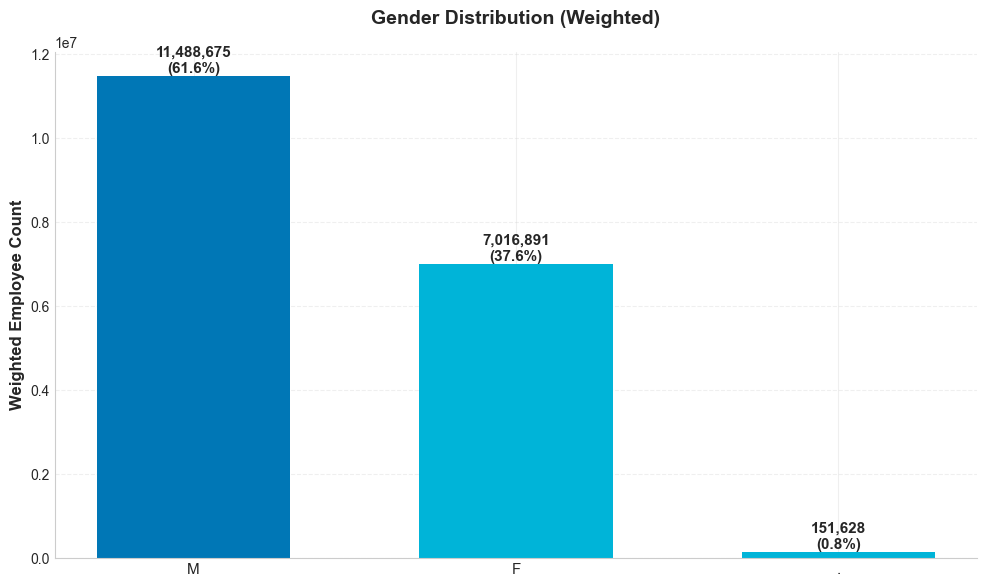

✓ Saved: output/company_overview/01_gender_distribution.png


In [8]:
# Visualize Gender Distribution - McKinsey Style (Weighted)
if gender_col:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    gender_data = weighted_value_counts(df, gender_col, 'weight')
    colors = [MCKINSEY_BLUE if i == 0 else MCKINSEY_LIGHT_BLUE for i in range(len(gender_data))]
    
    bars = ax.bar(range(len(gender_data)), gender_data.values, color=colors, width=0.6)
    
    # Add value labels on bars
    for i, (bar, val) in enumerate(zip(bars, gender_data.values)):
        height = bar.get_height()
        pct = (val / gender_data.sum() * 100)
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:,.0f}\n({pct:.1f}%)',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    ax.set_xticks(range(len(gender_data)))
    ax.set_xticklabels(gender_data.index, fontsize=11)
    ax.set_ylabel('Weighted Employee Count', fontsize=12, fontweight='bold')
    ax.set_title('Gender Distribution (Weighted)', fontsize=14, fontweight='bold', pad=20)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/01_gender_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: {output_dir}/01_gender_distribution.png")

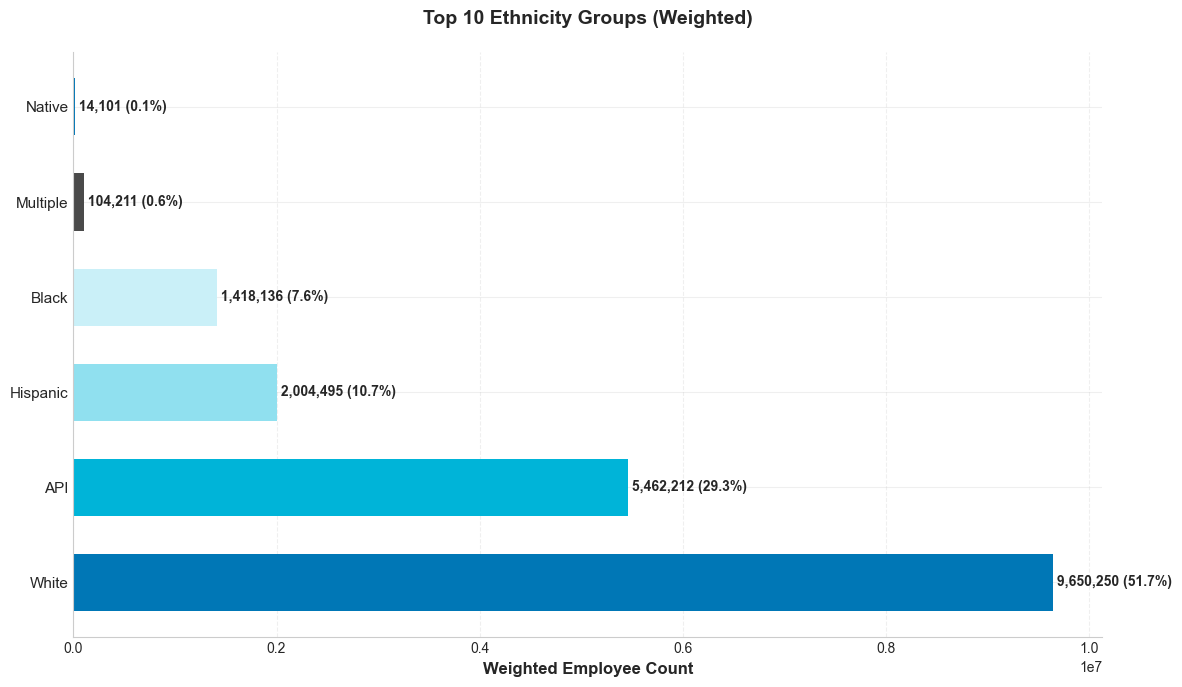

✓ Saved: output/company_overview/02_ethnicity_distribution.png


In [9]:
# Visualize Ethnicity Distribution - McKinsey Style (Weighted)
if ethnicity_col:
    fig, ax = plt.subplots(figsize=(12, 7))
    
    ethnicity_data = weighted_value_counts(df, ethnicity_col, 'weight').head(10)
    total_weight = weighted_value_counts(df, ethnicity_col, 'weight').sum()
    colors = [MCKINSEY_PALETTE[i % len(MCKINSEY_PALETTE)] for i in range(len(ethnicity_data))]
    
    bars = ax.barh(range(len(ethnicity_data)), ethnicity_data.values, color=colors, height=0.6)
    
    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, ethnicity_data.values)):
        width = bar.get_width()
        pct = (val / total_weight * 100)
        ax.text(width, bar.get_y() + bar.get_height()/2.,
                f' {val:,.0f} ({pct:.1f}%)',
                ha='left', va='center', fontsize=10, fontweight='bold')
    
    ax.set_yticks(range(len(ethnicity_data)))
    ax.set_yticklabels(ethnicity_data.index, fontsize=11)
    ax.set_xlabel('Weighted Employee Count', fontsize=12, fontweight='bold')
    ax.set_title('Top 10 Ethnicity Groups (Weighted)', fontsize=14, fontweight='bold', pad=20)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/02_ethnicity_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: {output_dir}/02_ethnicity_distribution.png")

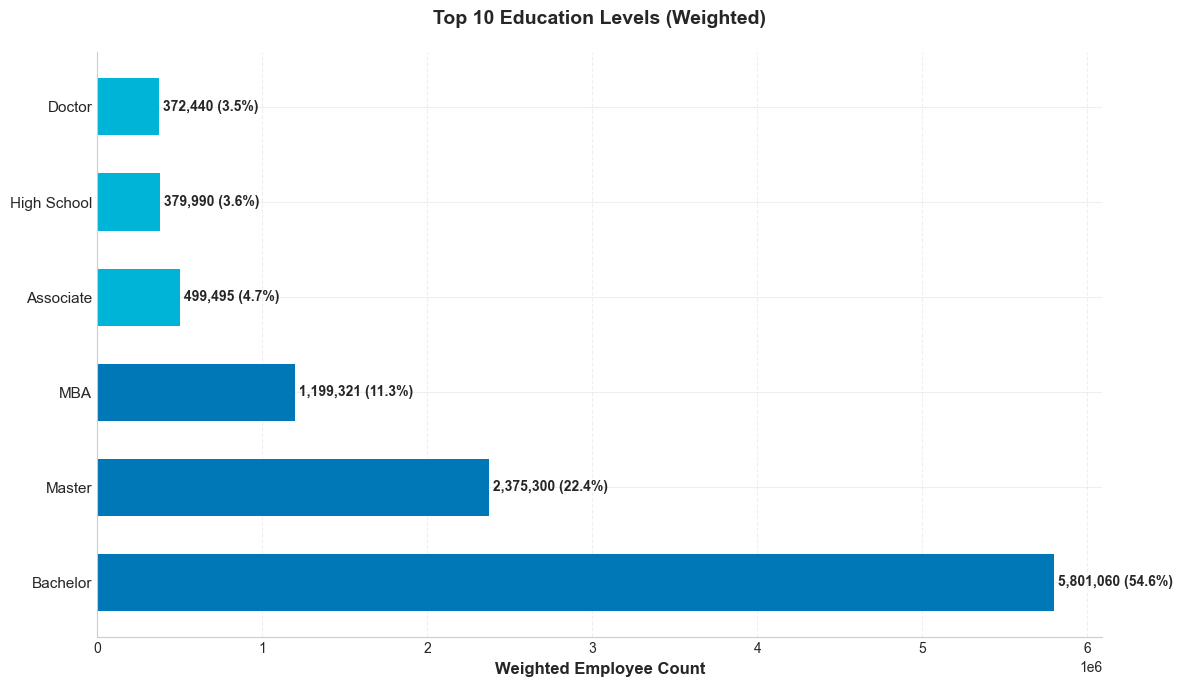

✓ Saved: output/company_overview/03_education_distribution.png


In [10]:
# Visualize Education Distribution - McKinsey Style (Weighted)
if education_col:
    fig, ax = plt.subplots(figsize=(12, 7))
    
    education_data = weighted_value_counts(df, education_col, 'weight').head(10)
    total_weight = weighted_value_counts(df, education_col, 'weight').sum()
    colors = [MCKINSEY_BLUE if i < 3 else MCKINSEY_LIGHT_BLUE for i in range(len(education_data))]
    
    bars = ax.barh(range(len(education_data)), education_data.values, color=colors, height=0.6)
    
    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, education_data.values)):
        width = bar.get_width()
        pct = (val / total_weight * 100)
        ax.text(width, bar.get_y() + bar.get_height()/2.,
                f' {val:,.0f} ({pct:.1f}%)',
                ha='left', va='center', fontsize=10, fontweight='bold')
    
    ax.set_yticks(range(len(education_data)))
    ax.set_yticklabels(education_data.index, fontsize=11)
    ax.set_xlabel('Weighted Employee Count', fontsize=12, fontweight='bold')
    ax.set_title('Top 10 Education Levels (Weighted)', fontsize=14, fontweight='bold', pad=20)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/03_education_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: {output_dir}/03_education_distribution.png")

---
## Section 1: Position Analysis
### Most Common Job Titles

In [11]:
# Use O*NET codes for position analysis (Weighted)
position_code_col = 'onet_code'
position_title_col = 'onets_title'

if position_code_col in df.columns and position_title_col in df.columns:
    print("=" * 60)
    print("TOP 20 MOST COMMON POSITIONS (WEIGHTED)")
    print("=" * 60)
    
    # Filter to only rows with valid O*NET titles (exclude unmapped codes)
    df_valid_positions = df[df[position_title_col].notna()].copy()
    
    # Group by onet_code and get the first onet_title for each code
    position_mapping = df_valid_positions.groupby(position_code_col)[position_title_col].first()
    
    # Weighted position counts (only for valid positions)
    position_counts = weighted_value_counts(df_valid_positions, position_code_col, 'weight').head(20)
    total_weight = weighted_value_counts(df_valid_positions, position_code_col, 'weight').sum()
    position_pct = (position_counts / total_weight * 100).round(2)
    
    # Create summary with titles
    position_summary = pd.DataFrame({
        'Position': [position_mapping[code] for code in position_counts.index],
        'Weighted Count': position_counts.values.round(0).astype(int),
        'Percentage': position_pct.values
    })
    
    display(position_summary)
    
    # Count statistics
    valid_unique = df_valid_positions[position_code_col].nunique()
    total_unique = df[position_code_col].nunique()
    unmapped_codes = total_unique - valid_unique
    
    print(f"\n📊 Total unique positions (O*NET codes with titles): {valid_unique:,}")
    if unmapped_codes > 0:
        print(f"⚠️ {unmapped_codes} O*NET codes excluded (not in reference data)")
else:
    print("⚠️ Position columns (onet_code, onets_title) not found in dataset")

TOP 20 MOST COMMON POSITIONS (WEIGHTED)


,Position,Weighted Count,Percentage
0,Software Developers,1263397,7.43
1,Information Technology Project Managers,566430,3.33
2,Business Intelligence Analysts,471498,2.77
3,Computer Systems Engineers/Architects,446691,2.63
4,"Sales Representatives, Wholesale and Manufactu...",442214,2.6
5,Sales Managers,365732,2.15
6,Customer Service Representatives,363498,2.14
7,Marketing Managers,360064,2.12
8,Treasurers and Controllers,320919,1.89
9,Retail Salespersons,298148,1.75



📊 Total unique positions (O*NET codes with titles): 916
⚠️ 93 O*NET codes excluded (not in reference data)


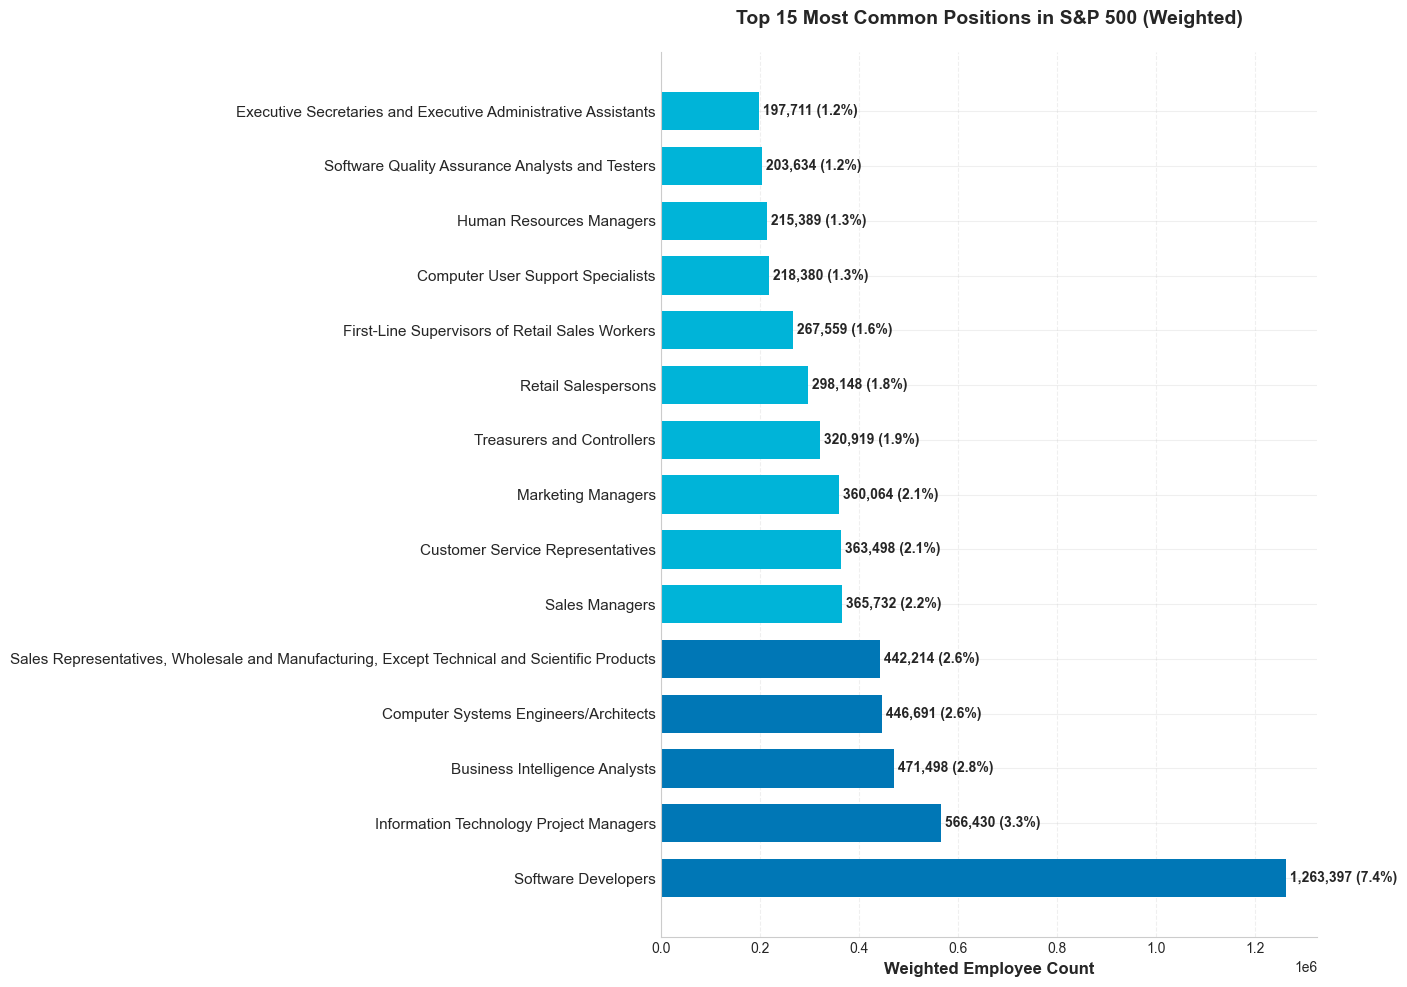

✓ Saved: output/company_overview/04_top_positions.png


In [12]:
# Visualize Top Positions - McKinsey Style (Weighted)
if position_code_col in df.columns and position_title_col in df.columns:
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # Use only rows with valid O*NET titles
    df_valid_positions = df[df[position_title_col].notna()].copy()
    
    # Get top 15 positions by weighted count
    top_codes = weighted_value_counts(df_valid_positions, position_code_col, 'weight').head(15)
    total_weight = df_valid_positions['weight'].sum()
    position_mapping = df_valid_positions.groupby(position_code_col)[position_title_col].first()
    position_titles = [position_mapping[code] for code in top_codes.index]
    
    colors = [MCKINSEY_BLUE if i < 5 else MCKINSEY_LIGHT_BLUE for i in range(len(top_codes))]
    
    bars = ax.barh(range(len(top_codes)), top_codes.values, color=colors, height=0.7)
    
    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, top_codes.values)):
        width = bar.get_width()
        pct = (val / total_weight * 100)
        ax.text(width, bar.get_y() + bar.get_height()/2.,
                f' {val:,.0f} ({pct:.1f}%)',
                ha='left', va='center', fontsize=10, fontweight='bold')
    
    ax.set_yticks(range(len(top_codes)))
    ax.set_yticklabels(position_titles, fontsize=11)
    ax.set_xlabel('Weighted Employee Count', fontsize=12, fontweight='bold')
    ax.set_title('Top 15 Most Common Positions in S&P 500 (Weighted)', fontsize=14, fontweight='bold', pad=20)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', alpha=0.3, linestyle='--')

    plt.tight_layout()
    plt.savefig(f'{output_dir}/04_top_positions.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: {output_dir}/04_top_positions.png")

---
## Section 2: Geographic Analysis
### Employee Location Mapping

In [13]:
# Load world cities data for coordinates
import zipfile

print("Loading world cities database...")
with zipfile.ZipFile('data/simplemaps_worldcities_basicv1.901.zip', 'r') as zip_ref:
    # Find the CSV file in the zip
    csv_files = [f for f in zip_ref.namelist() if f.endswith('.csv')]
    if csv_files:
        with zip_ref.open(csv_files[0]) as csv_file:
            cities_df = pd.read_csv(csv_file)
            print(f"✓ Loaded {len(cities_df):,} cities")
            print(f"\nCities columns: {cities_df.columns.tolist()}")
            display(cities_df.head())

Loading world cities database...
✓ Loaded 48,059 cities

Cities columns: ['city', 'city_ascii', 'lat', 'lng', 'country', 'iso2', 'iso3', 'admin_name', 'capital', 'population', 'id']


,city,city_ascii,lat,lng,country,iso2,iso3,admin_name,capital,population,id
0,Tokyo,Tokyo,35.6870,139.7495,Japan,JP,JPN,Tōkyō,primary,37785000.0,1392685764
1,Jakarta,Jakarta,-6.1750,106.8275,Indonesia,ID,IDN,Jakarta,primary,33756000.0,1360771077
2,Delhi,Delhi,28.6100,77.2300,India,IN,IND,Delhi,admin,32226000.0,1356872604
3,Guangzhou,Guangzhou,23.1300,113.2600,China,CN,CHN,Guangdong,admin,26940000.0,1156237133
4,Mumbai,Mumbai,19.0761,72.8775,India,IN,IND,Mahārāshtra,admin,24973000.0,1356226629


In [14]:
# Find city column in employee data
city_col = None
for col in df.columns:
    if 'city' in col.lower() or 'location' in col.lower():
        city_col = col
        break

if city_col:
    print(f"Found city column: {city_col}")
    print(f"\nTop 10 cities in employee data:")
    display(df[city_col].value_counts().head(10))
else:
    print("⚠️ City column not found. Will check for other location columns...")
    location_cols = [col for col in df.columns if any(kw in col.lower() for kw in ['city', 'location', 'place', 'region'])]
    print(f"Potential location columns: {location_cols}")

Found city column: ethnicity_predicted

Top 10 cities in employee data:


ethnicity_predicted
White       8649221
API         4290645
Hispanic    1728431
Black       1244949
Multiple      87662
Native        12368
Name: count, dtype: Int64

In [15]:
# Merge employee data with city coordinates
if city_col:
    # Prepare city names for matching
    df['city_clean'] = df[city_col].astype(str).str.strip().str.lower()
    cities_df['city_clean'] = cities_df['city'].astype(str).str.strip().str.lower()
    
    # Merge on city name
    df_geo = df.merge(
        cities_df[['city_clean', 'lat', 'lng', 'country']],
        on='city_clean',
        how='left'
    )
    
    # Use weighted count
    matched_weight = df_geo.loc[df_geo['lat'].notna(), 'weight'].sum()
    total_weight = df_geo['weight'].sum()
    match_rate = (matched_weight / total_weight * 100)
    
    print(f"\n📍 Successfully matched {matched_weight:,.0f} / {total_weight:,.0f} weighted employees ({match_rate:.1f}%)")
    print(f"\nTop 10 employee locations (weighted):")
    location_counts = df_geo[df_geo['lat'].notna()].groupby(city_col)['weight'].sum().sort_values(ascending=False).head(10)
    display(location_counts.round(0).astype(int))
else:
    print("⚠️ Cannot proceed with geographic analysis without city data")


📍 Successfully matched 9,650,250 / 18,657,194 weighted employees (51.7%)

Top 10 employee locations (weighted):


ethnicity_predicted
White    9650250
Name: weight, dtype: int64

In [16]:
# Create interactive map with employee locations - McKinsey Style (USA only, Weighted)
if city_col and 'lat' in df_geo.columns:
    # Aggregate by location (weighted)
    map_data = df_geo[df_geo['lat'].notna()].groupby(
        [city_col, 'lat', 'lng']
    )['weight'].sum().reset_index(name='employee_count')
    
    # Create map using scatter_mapbox for actual map visualization
    fig = px.scatter_mapbox(
        map_data,
        lat='lat',
        lon='lng',
        size='employee_count',
        hover_name=city_col,
        hover_data={
            'employee_count': ':,',
            'lat': ':.4f',
            'lng': ':.4f'
        },
        color='employee_count',
        color_continuous_scale=[
            [0, '#FFE5E5'],
            [0.5, '#FF6B6B'],
            [1, '#CC0000']
        ],
        size_max=50,
        zoom=3,
        center={'lat': 37.0902, 'lon': -95.7129},  # Center of USA
        title='<b>S&P 500 Employee Geographic Distribution (USA)</b>',
        mapbox_style='open-street-map'  # Use OpenStreetMap for free map tiles
    )
    
    fig.update_layout(
        font=dict(family="Arial, sans-serif", size=12),
        title_font=dict(size=16, color='#4A4A4A'),
        coloraxis_colorbar=dict(
            title="Employees",
            tickformat=','
        ),
        height=700,
        margin={"r":0,"t":50,"l":0,"b":0}
    )
    
    # fig.write_html(f'{output_dir}/05_employee_geographic_map.html')
    # fig.show()
    # print(f"✓ Saved: {output_dir}/05_employee_geographic_map.html")

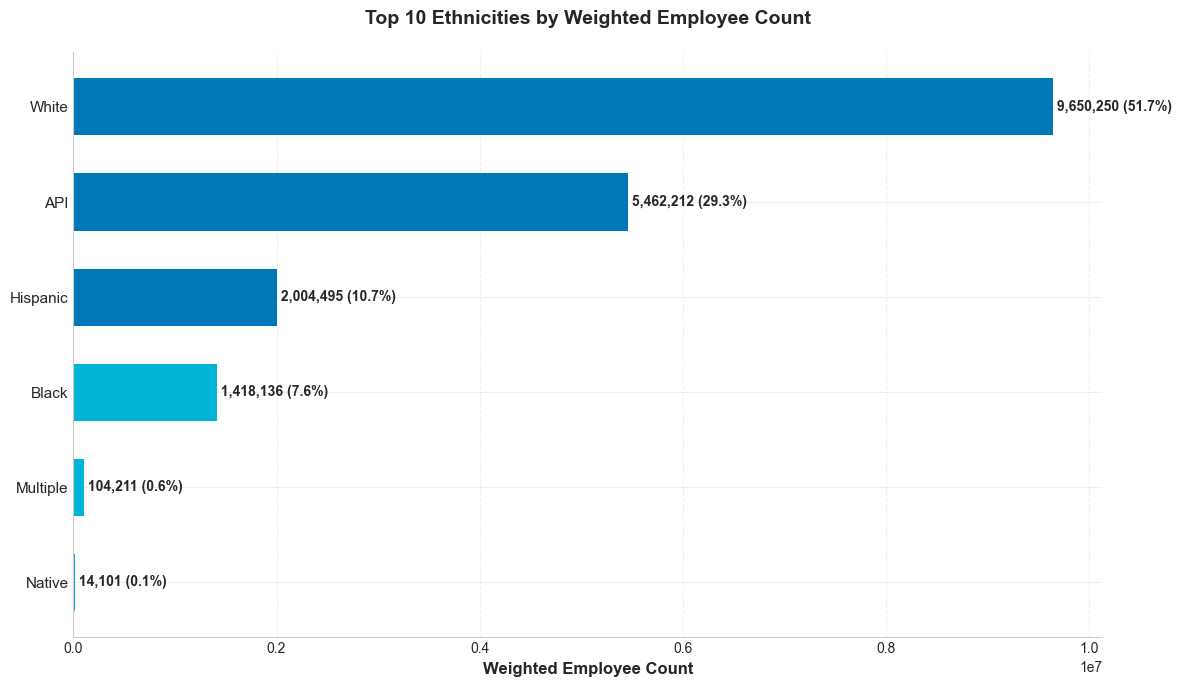

✓ Saved: output/company_overview/06_top_cities.png


In [23]:
# Top 10 cities visualization - McKinsey Style (Weighted)
if city_col:
    fig, ax = plt.subplots(figsize=(12, 7))
    
    city_data = weighted_value_counts(df, city_col, 'weight').head(10)
    total_weight = df['weight'].sum()
    colors = [MCKINSEY_BLUE if i < 3 else MCKINSEY_LIGHT_BLUE for i in range(len(city_data))]
    
    bars = ax.barh(range(len(city_data)), city_data.values, color=colors, height=0.6)
    
    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, city_data.values)):
        width = bar.get_width()
        pct = (val / total_weight * 100)
        ax.text(width, bar.get_y() + bar.get_height()/2.,
                f' {val:,.0f} ({pct:.1f}%)',
                ha='left', va='center', fontsize=10, fontweight='bold')
    
    ax.set_yticks(range(len(city_data)))
    ax.set_yticklabels(city_data.index, fontsize=11)
    ax.set_xlabel('Weighted Employee Count', fontsize=12, fontweight='bold')
    ax.set_title('Top 10 Ethnicities by Weighted Employee Count', fontsize=14, fontweight='bold', pad=20)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.invert_yaxis()
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/06_top_cities.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: {output_dir}/06_top_cities.png")

---
## Section 3: Remote Work Analysis
### Remote Suitability Distribution

In [18]:
# Find remote work column
remote_col = None
for col in df.columns:
    if any(keyword in col.lower() for keyword in ['remote', 'wfh', 'work_from_home', 'telework']):
        remote_col = col
        break

if remote_col:
    print("=" * 60)
    print("REMOTE WORK SUITABILITY ANALYSIS (WEIGHTED)")
    print("=" * 60)
    
    # Weighted remote counts
    remote_counts = weighted_value_counts(df, remote_col, 'weight')
    total_weight = remote_counts.sum()
    remote_pct = (remote_counts / total_weight * 100).round(2)
    
    remote_summary = pd.DataFrame({
        'Weighted Count': remote_counts.round(0).astype(int),
        'Percentage': remote_pct
    })
    
    display(remote_summary)
    
    print(f"\n📊 Remote work data available for: {df.loc[df[remote_col].notna(), 'weight'].sum():,.0f} weighted employees")
else:
    print("⚠️ Remote work column not found in dataset")
    print("Searching for related columns...")
    work_cols = [col for col in df.columns if any(kw in col.lower() for kw in ['work', 'office', 'location'])]
    print(f"Potential work-related columns: {work_cols}")

⚠️ Remote work column not found in dataset
Searching for related columns...
Potential work-related columns: []


In [19]:
3
if remote_col:
    # Try different visualizations based on data type
    if df[remote_col].dtype in ['int64', 'float64']:
        # Numeric remote suitability score
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        
        # Distribution plot
        ax1.hist(df[remote_col].dropna(), bins=30, color=MCKINSEY_BLUE, 
                edgecolor='white', alpha=0.8)
        ax1.axvline(df[remote_col].mean(), color=MCKINSEY_GRAY, 
                   linestyle='--', linewidth=2, label=f'Mean: {df[remote_col].mean():.2f}')
        ax1.axvline(df[remote_col].median(), color='#FF6B6B', 
                   linestyle='--', linewidth=2, label=f'Median: {df[remote_col].median():.2f}')
        ax1.set_xlabel('Remote Suitability Score', fontsize=12, fontweight='bold')
        ax1.set_ylabel('Frequency', fontsize=12, fontweight='bold')
        ax1.set_title('Remote Work Suitability Distribution', fontsize=14, fontweight='bold', pad=20)
        ax1.spines['top'].set_visible(False)
        ax1.spines['right'].set_visible(False)
        ax1.legend()
        ax1.grid(axis='y', alpha=0.3, linestyle='--')
        
        # Box plot
        bp = ax2.boxplot(df[remote_col].dropna(), vert=True, patch_artist=True,
                        widths=0.5,
                        boxprops=dict(facecolor=MCKINSEY_LIGHT_BLUE, edgecolor=MCKINSEY_BLUE, linewidth=2),
                        whiskerprops=dict(color=MCKINSEY_BLUE, linewidth=2),
                        capprops=dict(color=MCKINSEY_BLUE, linewidth=2),
                        medianprops=dict(color='#FF6B6B', linewidth=2.5),
                        flierprops=dict(marker='o', markerfacecolor=MCKINSEY_GRAY, 
                                       markersize=6, alpha=0.5))
        ax2.set_ylabel('Remote Suitability Score', fontsize=12, fontweight='bold')
        ax2.set_title('Remote Work Suitability Range', fontsize=14, fontweight='bold', pad=20)
        ax2.spines['top'].set_visible(False)
        ax2.spines['right'].set_visible(False)
        ax2.grid(axis='y', alpha=0.3, linestyle='--')
        ax2.set_xticklabels(['All Employees'])
        
        plt.tight_layout()
        plt.savefig(f'{output_dir}/07_remote_work_numeric.png', dpi=300, bbox_inches='tight')
        plt.show()
        print(f"✓ Saved: {output_dir}/07_remote_work_numeric.png")
        
        # Summary statistics
        print(f"\n📊 Remote Suitability Statistics:")
        print(f"   Mean: {df[remote_col].mean():.2f}")
        print(f"   Median: {df[remote_col].median():.2f}")
        print(f"   Std Dev: {df[remote_col].std():.2f}")
        print(f"   Min: {df[remote_col].min():.2f}")
        print(f"   Max: {df[remote_col].max():.2f}")
        
    else:
        # Categorical remote work data - use density/distribution plot
        fig, ax = plt.subplots(figsize=(12, 7))
        
        # Convert categorical to numeric for density plot
        remote_data_clean = df[remote_col].dropna()
        
        # Create a density plot
        from scipy import stats
        
        # If data is categorical, convert to numeric codes
        if remote_data_clean.dtype == 'object':
            remote_numeric = pd.Categorical(remote_data_clean).codes
        else:
            remote_numeric = remote_data_clean
        
        # Create density plot
        density = stats.gaussian_kde(remote_numeric)
        x_range = np.linspace(remote_numeric.min(), remote_numeric.max(), 200)
        
        ax.fill_between(x_range, density(x_range), alpha=0.6, color=MCKINSEY_LIGHT_BLUE)
        ax.plot(x_range, density(x_range), color=MCKINSEY_BLUE, linewidth=3)
        
        # Add mean line
        mean_val = remote_numeric.mean()
        ax.axvline(mean_val, color=MCKINSEY_GRAY, linestyle='--', linewidth=2, 
                   label=f'Mean: {mean_val:.2f}')
        
        ax.set_xlabel('Remote Work Category Distribution', fontsize=12, fontweight='bold')
        ax.set_ylabel('Density', fontsize=12, fontweight='bold')
        ax.set_title('Remote Work Status Distribution', fontsize=14, fontweight='bold', pad=20)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.legend()
        
        # Add summary statistics as text
        unique_count = df[remote_col].nunique()
        most_common = df[remote_col].value_counts().iloc[0]
        most_common_pct = (most_common / len(df[remote_col].dropna()) * 100)
        
        stats_text = f'Unique Categories: {unique_count}\nMost Common: {most_common:,} ({most_common_pct:.1f}%)'
        ax.text(0.98, 0.97, stats_text, transform=ax.transAxes,
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor=MCKINSEY_GRAY),
                fontsize=10)
        
        plt.tight_layout()
        plt.savefig(f'{output_dir}/07_remote_work_distribution.png', dpi=300, bbox_inches='tight')
        plt.show()
        print(f"✓ Saved: {output_dir}/07_remote_work_distribution.png")

---
## Section 4: Compensation Analysis
### Salary Distribution and Insights

In [20]:
# Find salary column
salary_col = None
for col in df.columns:
    if any(keyword in col.lower() for keyword in ['salary', 'compensation', 'pay', 'wage', 'income']):
        salary_col = col
        break

if salary_col:
    print("=" * 60)
    print("SALARY ANALYSIS (WEIGHTED)")
    print("=" * 60)
    
    # Weighted salary statistics
    salary_data = df[[salary_col, 'weight']].dropna()
    total_weight = salary_data['weight'].sum()
    
    w_mean = weighted_mean(df, salary_col, 'weight')
    w_median = weighted_percentile(df, salary_col, 0.5, 'weight')
    w_std = weighted_std(df, salary_col, 'weight')
    w_25 = weighted_percentile(df, salary_col, 0.25, 'weight')
    w_75 = weighted_percentile(df, salary_col, 0.75, 'weight')
    
    print(f"\n📊 Weighted Salary Statistics:")
    print(f"   Total weighted count: {total_weight:,.0f}")
    print(f"   Weighted Mean: ${w_mean:,.2f}")
    print(f"   Weighted Median: ${w_median:,.2f}")
    print(f"   Weighted Std Dev: ${w_std:,.2f}")
    print(f"   Min: ${salary_data[salary_col].min():,.2f}")
    print(f"   25th percentile (weighted): ${w_25:,.2f}")
    print(f"   75th percentile (weighted): ${w_75:,.2f}")
    print(f"   Max: ${salary_data[salary_col].max():,.2f}")
else:
    print("⚠️ Salary column not found in dataset")
    comp_cols = [col for col in df.columns if any(kw in col.lower() for kw in ['salary', 'pay', 'comp', 'wage', 'income'])]
    print(f"Potential compensation columns: {comp_cols}")

SALARY ANALYSIS (WEIGHTED)

📊 Weighted Salary Statistics:
   Total weighted count: 18,654,548
   Weighted Mean: $69,875.30
   Weighted Median: $49,433.54
   Weighted Std Dev: $61,859.88
   Min: $0.00
   25th percentile (weighted): $25,421.06
   75th percentile (weighted): $98,997.24
   Max: $2,327,948.35


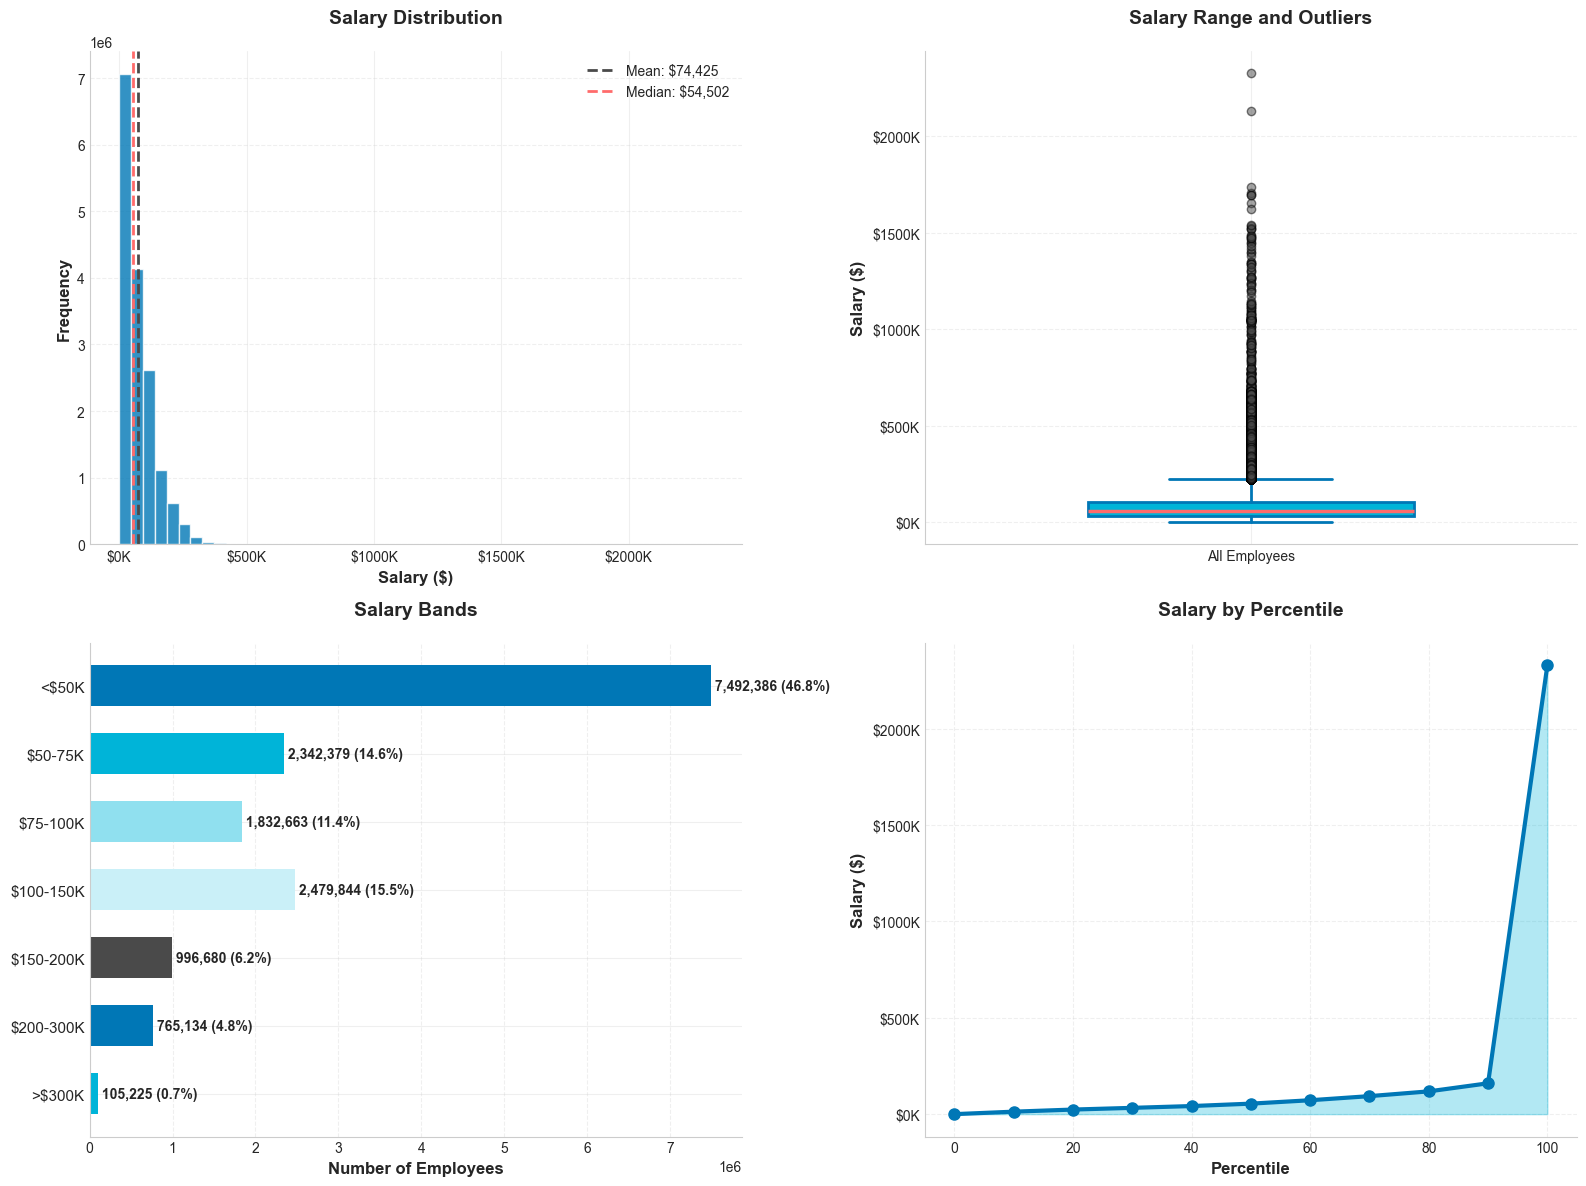

✓ Saved: output/company_overview/08_salary_distribution.png


In [21]:
# Visualize Salary Distribution - McKinsey Style
if salary_col:
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    
    salary_data = df[salary_col].dropna()
    
    # 1. Histogram
    ax1.hist(salary_data, bins=50, color=MCKINSEY_BLUE, edgecolor='white', alpha=0.8)
    ax1.axvline(salary_data.mean(), color=MCKINSEY_GRAY, 
               linestyle='--', linewidth=2, label=f'Mean: ${salary_data.mean():,.0f}')
    ax1.axvline(salary_data.median(), color='#FF6B6B', 
               linestyle='--', linewidth=2, label=f'Median: ${salary_data.median():,.0f}')
    ax1.set_xlabel('Salary ($)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax1.set_title('Salary Distribution', fontsize=14, fontweight='bold', pad=20)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3, linestyle='--')
    ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))
    
    # 2. Box plot
    bp = ax2.boxplot(salary_data, vert=True, patch_artist=True,
                    widths=0.5,
                    boxprops=dict(facecolor=MCKINSEY_LIGHT_BLUE, edgecolor=MCKINSEY_BLUE, linewidth=2),
                    whiskerprops=dict(color=MCKINSEY_BLUE, linewidth=2),
                    capprops=dict(color=MCKINSEY_BLUE, linewidth=2),
                    medianprops=dict(color='#FF6B6B', linewidth=2.5),
                    flierprops=dict(marker='o', markerfacecolor=MCKINSEY_GRAY, 
                                   markersize=6, alpha=0.5))
    ax2.set_ylabel('Salary ($)', fontsize=12, fontweight='bold')
    ax2.set_title('Salary Range and Outliers', fontsize=14, fontweight='bold', pad=20)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.grid(axis='y', alpha=0.3, linestyle='--')
    ax2.set_xticklabels(['All Employees'])
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))
    
    # 3. Salary bands
    bins = [0, 50000, 75000, 100000, 150000, 200000, 300000, salary_data.max()]
    labels = ['<$50K', '$50-75K', '$75-100K', '$100-150K', '$150-200K', '$200-300K', '>$300K']
    salary_bands = pd.cut(salary_data, bins=bins, labels=labels)
    band_counts = salary_bands.value_counts().sort_index()
    
    colors = [MCKINSEY_PALETTE[i % len(MCKINSEY_PALETTE)] for i in range(len(band_counts))]
    bars = ax3.barh(range(len(band_counts)), band_counts.values, color=colors, height=0.6)
    
    for i, (bar, val) in enumerate(zip(bars, band_counts.values)):
        width = bar.get_width()
        pct = (val / len(salary_data) * 100)
        ax3.text(width, bar.get_y() + bar.get_height()/2.,
                f' {val:,} ({pct:.1f}%)',
                ha='left', va='center', fontsize=10, fontweight='bold')
    
    ax3.set_yticks(range(len(band_counts)))
    ax3.set_yticklabels(band_counts.index, fontsize=11)
    ax3.set_xlabel('Number of Employees', fontsize=12, fontweight='bold')
    ax3.set_title('Salary Bands', fontsize=14, fontweight='bold', pad=20)
    ax3.spines['top'].set_visible(False)
    ax3.spines['right'].set_visible(False)
    ax3.grid(axis='x', alpha=0.3, linestyle='--')
    ax3.invert_yaxis()
    
    # 4. Percentile chart
    percentiles = np.arange(0, 101, 10)
    percentile_values = [salary_data.quantile(p/100) for p in percentiles]
    
    ax4.plot(percentiles, percentile_values, color=MCKINSEY_BLUE, linewidth=3, marker='o', markersize=8)
    ax4.fill_between(percentiles, percentile_values, alpha=0.3, color=MCKINSEY_LIGHT_BLUE)
    ax4.set_xlabel('Percentile', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Salary ($)', fontsize=12, fontweight='bold')
    ax4.set_title('Salary by Percentile', fontsize=14, fontweight='bold', pad=20)
    ax4.spines['top'].set_visible(False)
    ax4.spines['right'].set_visible(False)
    ax4.grid(alpha=0.3, linestyle='--')
    ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/08_salary_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: {output_dir}/08_salary_distribution.png")


=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
WEIGHTED AVERAGE SALARY BY TOP POSITIONS


,Position,Weighted Mean Salary,Weighted Count
onet_code,,,
11-2021.00,Marketing Managers,110200.76,359991
15-1299.09,Information Technology Project Managers,97391.07,566354
11-3031.01,Treasurers and Controllers,88344.93,320876
15-1299.08,Computer Systems Engineers/Architects,87942.19,446636
15-1252.00,Software Developers,82873.30,1263222
11-2022.00,Sales Managers,82685.34,365681
11-3121.00,Human Resources Managers,77832.62,215365
15-2051.01,Business Intelligence Analysts,65052.70,471451
15-1253.00,Software Quality Assurance Analysts and Testers,59596.92,203615


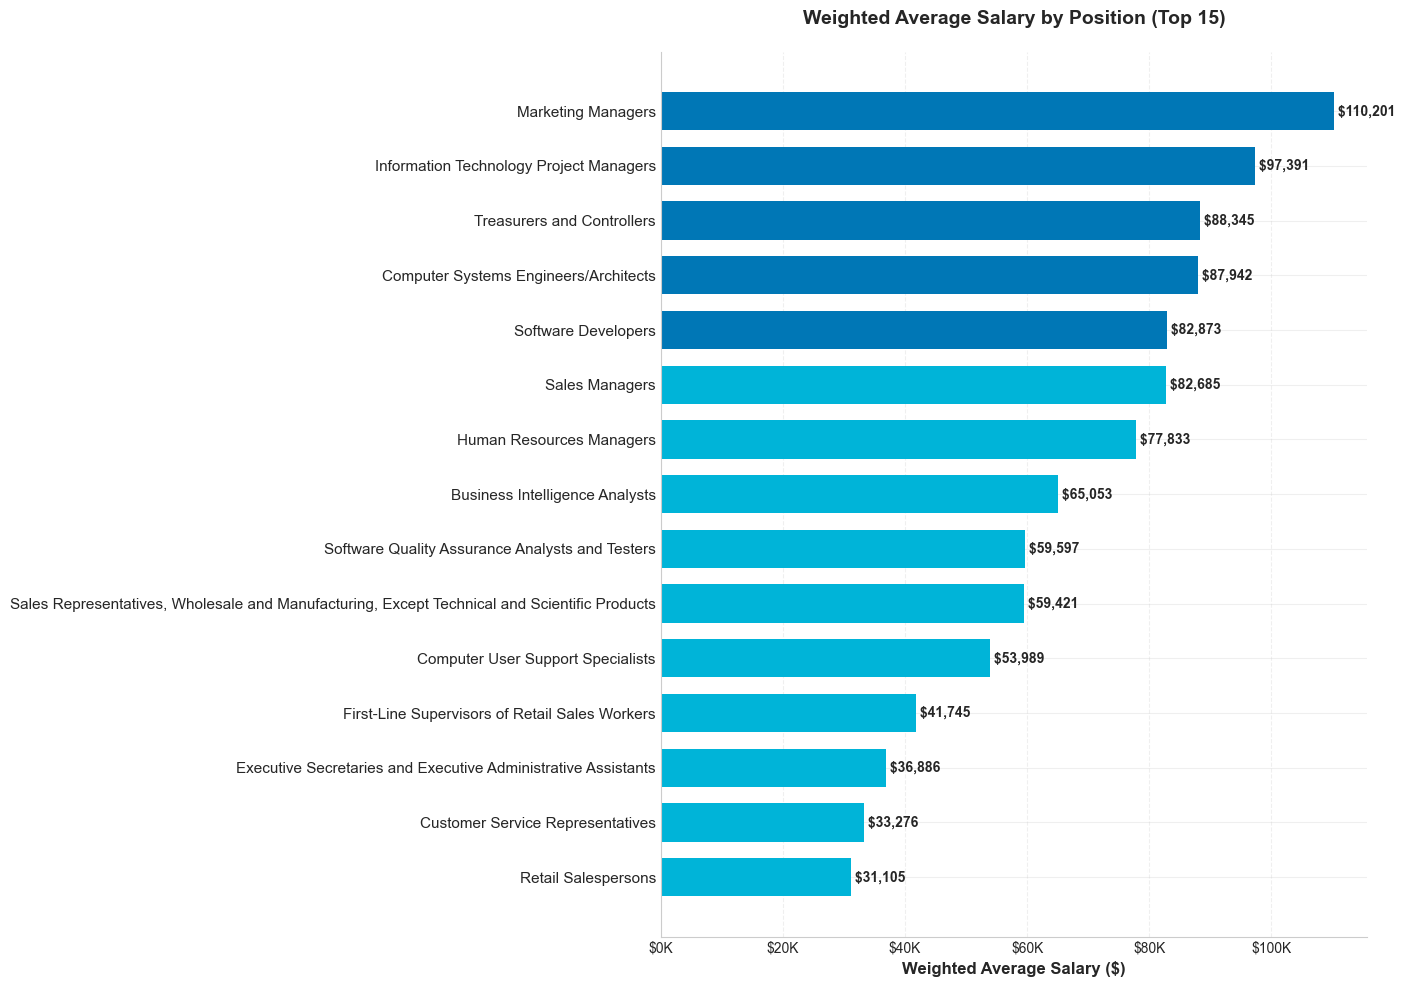

✓ Saved: output/company_overview/09_salary_by_position.png


In [22]:
# Salary by Position (if both columns exist) - Weighted
if salary_col and position_code_col in df.columns and position_title_col in df.columns:
    print("\n=" * 60)
    print("WEIGHTED AVERAGE SALARY BY TOP POSITIONS")
    print("=" * 60)
    
    # Filter to only rows with valid O*NET titles
    df_valid_positions = df[df[position_title_col].notna()].copy()
    
    # Get top 15 positions by weighted count (using onet_code)
    top_position_codes = weighted_value_counts(df_valid_positions, position_code_col, 'weight').head(15).index
    
    # Calculate weighted mean and median for each position
    def weighted_agg(group):
        valid = group[[salary_col, 'weight']].dropna()
        if len(valid) == 0:
            return pd.Series({'weighted_mean': np.nan, 'weighted_count': 0})
        w_mean = np.average(valid[salary_col], weights=valid['weight'])
        w_count = valid['weight'].sum()
        return pd.Series({'weighted_mean': w_mean, 'weighted_count': w_count})
    
    salary_by_position = df_valid_positions[df_valid_positions[position_code_col].isin(top_position_codes)].groupby(position_code_col).apply(weighted_agg).sort_values('weighted_mean', ascending=False)
    
    salary_by_position['weighted_mean'] = salary_by_position['weighted_mean'].round(2)
    salary_by_position['weighted_count'] = salary_by_position['weighted_count'].round(0).astype(int)
    
    # Add position titles to the display
    position_mapping = df_valid_positions.groupby(position_code_col)[position_title_col].first()
    salary_by_position['Position'] = [position_mapping[code] for code in salary_by_position.index]
    salary_by_position = salary_by_position[['Position', 'weighted_mean', 'weighted_count']]
    salary_by_position.columns = ['Position', 'Weighted Mean Salary', 'Weighted Count']
    
    display(salary_by_position)
    
    # Visualize
    fig, ax = plt.subplots(figsize=(14, 10))
    
    position_codes = salary_by_position.head(15).index
    position_titles = [position_mapping[code] for code in position_codes]
    means = salary_by_position.head(15)['Weighted Mean Salary'].values
    
    colors = [MCKINSEY_BLUE if i < 5 else MCKINSEY_LIGHT_BLUE for i in range(len(position_codes))]
    bars = ax.barh(range(len(position_codes)), means, color=colors, height=0.7)
    
    for i, (bar, val) in enumerate(zip(bars, means)):
        width = bar.get_width()
        ax.text(width, bar.get_y() + bar.get_height()/2.,
                f' ${val:,.0f}',
                ha='left', va='center', fontsize=10, fontweight='bold')
    
    ax.set_yticks(range(len(position_codes)))
    ax.set_yticklabels(position_titles, fontsize=11)
    ax.set_xlabel('Weighted Average Salary ($)', fontsize=12, fontweight='bold')
    ax.set_title('Weighted Average Salary by Position (Top 15)', fontsize=14, fontweight='bold', pad=20)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.invert_yaxis()
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/09_salary_by_position.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: {output_dir}/09_salary_by_position.png")

---
## Summary

This report provides a comprehensive **weighted** analysis of the S&P 500 workforce including:
- **Demographic statistics** (gender, ethnicity, education)
- **Position analysis** (most common roles)
- **Geographic distribution** (employee locations mapped globally)
- **Remote work patterns** (suitability and distribution)
- **Compensation analysis** (salary distributions and bands)

All statistics and visualizations use the `weight` column for proper sampling adjustment.
All visualizations follow McKinsey-style professional formatting suitable for executive presentations.